#  Uber Trip Analysis.

**Domain:** Data Analyst  
**Tools:** Python, Jupyter Notebook  
**Dataset:** `Uber-Jan-Feb-FOIL.csv` – Aggregated daily Uber trip statistics (Jan–Feb 2015)

In [26]:
!pip install xgboost

## 1. Import Libraries

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print(' Libraries imported successfully')

 Libraries imported successfully


## 2. Load & Inspect the Dataset

In [28]:
df = pd.read_csv('Uber-Jan-Feb-FOIL.csv')

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.head(10)

Shape: (354, 4)

Column names: ['dispatching_base_number', 'date', 'active_vehicles', 'trips']


,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537
5,B02598,1/1/2015,870,6903
6,B02598,1/2/2015,785,4768
7,B02617,1/2/2015,1137,7065
8,B02512,1/2/2015,175,875
9,B02682,1/2/2015,890,5506


In [29]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nBasic stats:')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB
None

Missing values:
dispatching_base_number    0
date                       0
active_vehicles            0
trips                      0
dtype: int64

Basic stats:


,active_vehicles,trips
count,354.000000,354.000000
mean,1307.435028,11667.316384
std,1162.510626,10648.284865
min,112.000000,629.000000
25%,296.750000,2408.500000
50%,1077.000000,9601.000000
75%,1417.000000,13711.250000
max,4395.000000,45858.000000


## 3. Data Preprocessing

In [30]:
df.rename(columns={
    'dispatching_base_number': 'Base',
    'date': 'Date',
    'active_vehicles': 'Active_Vehicles',
    'trips': 'Trips'
}, inplace=True)

df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

df['Day']       = df['Date'].dt.day
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek          # 0=Mon … 6=Sun
df['WeekOfYear']= df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['DayName']   = df['Date'].dt.day_name()

base_names = {
    'B02512': 'Unter',
    'B02765': 'Grun',
    'B02764': 'Danach-NY',
    'B02682': 'Schmecken',
    'B02598': 'Hinter',
    'B02617': 'Weiter',
    'B02835': 'Dreist',
    'B02836': 'Drinnen'
}
df['Base_Name'] = df['Base'].map(base_names).fillna(df['Base'])

print('Preprocessing complete. Shape:', df.shape)
df.head()

Preprocessing complete. Shape: (354, 11)


,Base,Date,Active_Vehicles,Trips,Day,Month,DayOfWeek,WeekOfYear,IsWeekend,DayName,Base_Name
0,B02512,2015-01-01,190,1132,1,1,3,1,0,Thursday,Unter
1,B02765,2015-01-01,225,1765,1,1,3,1,0,Thursday,Grun
2,B02764,2015-01-01,3427,29421,1,1,3,1,0,Thursday,Danach-NY
3,B02682,2015-01-01,945,7679,1,1,3,1,0,Thursday,Schmecken
4,B02617,2015-01-01,1228,9537,1,1,3,1,0,Thursday,Weiter


## 4. Exploratory Data Analysis (EDA)

### 4.1 – Total daily trips across all bases

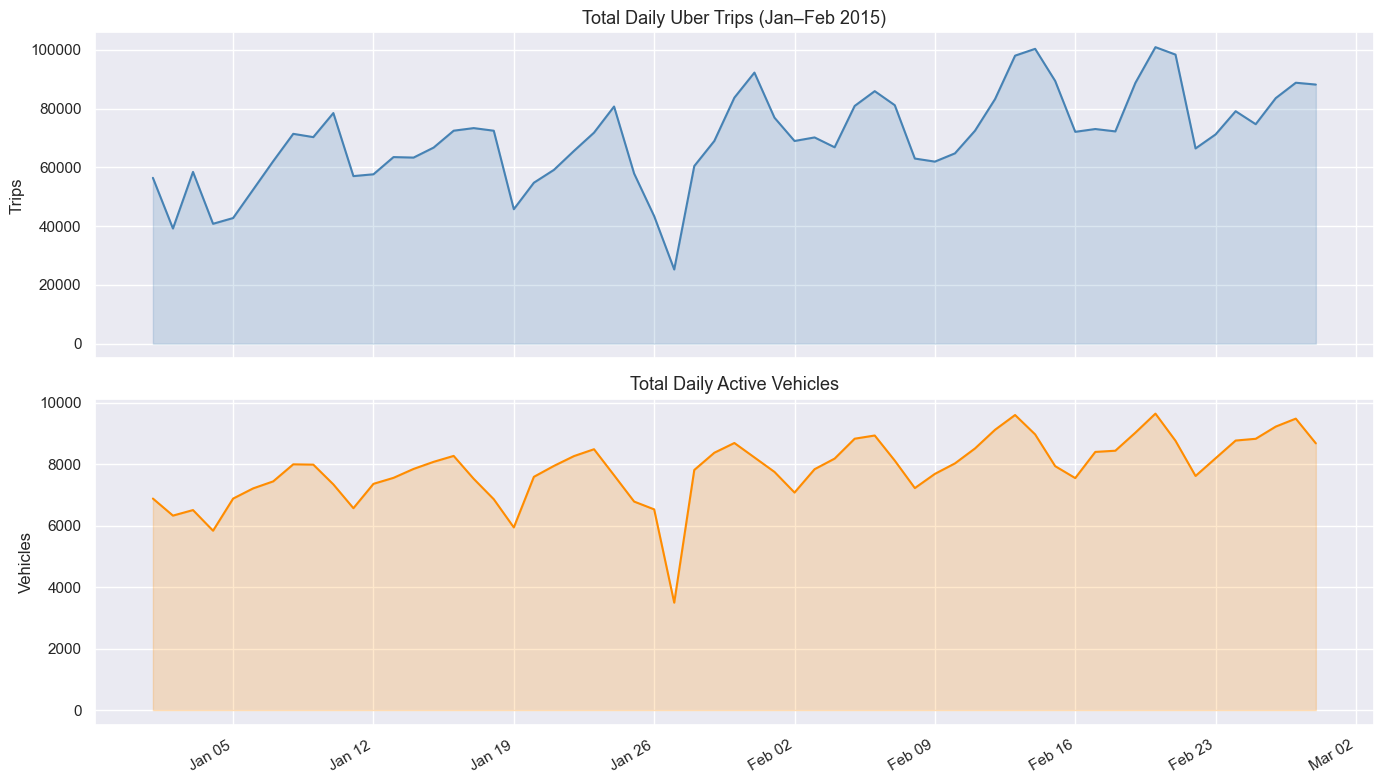

In [31]:
daily_total = df.groupby('Date')[['Trips', 'Active_Vehicles']].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily_total['Date'], daily_total['Trips'], color='steelblue', lw=1.5)
axes[0].fill_between(daily_total['Date'], daily_total['Trips'], alpha=0.2, color='steelblue')
axes[0].set_title('Total Daily Uber Trips (Jan–Feb 2015)', fontsize=13)
axes[0].set_ylabel('Trips')

axes[1].plot(daily_total['Date'], daily_total['Active_Vehicles'], color='darkorange', lw=1.5)
axes[1].fill_between(daily_total['Date'], daily_total['Active_Vehicles'], alpha=0.2, color='darkorange')
axes[1].set_title('Total Daily Active Vehicles', fontsize=13)
axes[1].set_ylabel('Vehicles')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 4.2 – Trips by Day of the Week

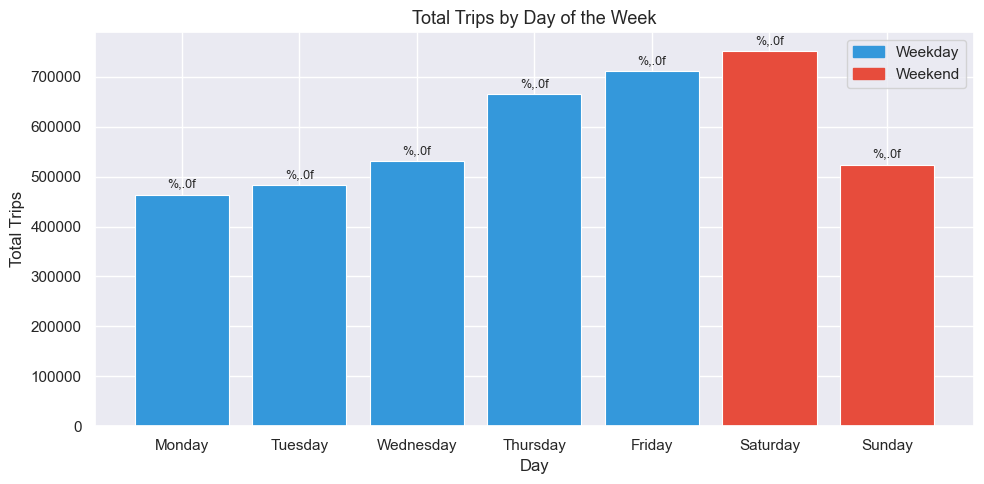

In [32]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_df = df.groupby('DayName')['Trips'].sum().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if d in ['Saturday','Sunday'] else '#3498db' for d in dow_order]
bars = ax.bar(dow_df.index, dow_df.values, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%,.0f', padding=3, fontsize=9)
ax.set_title('Total Trips by Day of the Week', fontsize=13)
ax.set_xlabel('Day')
ax.set_ylabel('Total Trips')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#3498db', label='Weekday'),
    plt.Rectangle((0,0),1,1, color='#e74c3c', label='Weekend')
])
plt.tight_layout()
plt.show()

### 4.3 – Trips by Uber Base

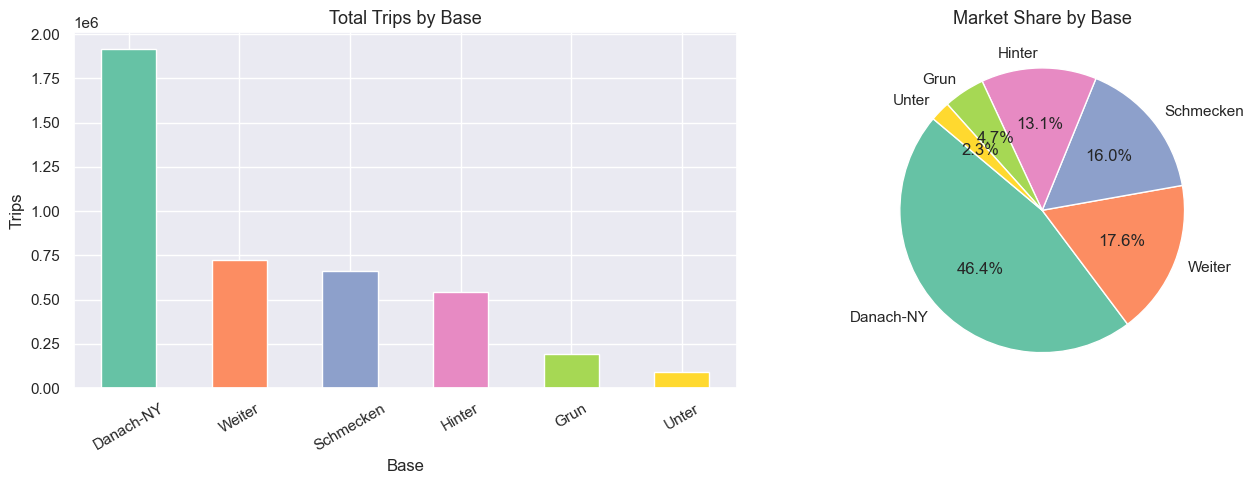


Trips per Base:
Base_Name
Danach-NY    1914449
Weiter        725025
Schmecken     662509
Hinter        540791
Grun          193670
Unter          93786


In [33]:
base_trips = df.groupby('Base_Name')['Trips'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
base_trips.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(base_trips)),
                edgecolor='white')
axes[0].set_title('Total Trips by Base', fontsize=13)
axes[0].set_xlabel('Base')
axes[0].set_ylabel('Trips')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(base_trips.values, labels=base_trips.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(base_trips)), startangle=140)
axes[1].set_title('Market Share by Base', fontsize=13)

plt.tight_layout()
plt.show()

print('\nTrips per Base:')
print(base_trips.to_string())

### 4.4 – January vs February Comparison

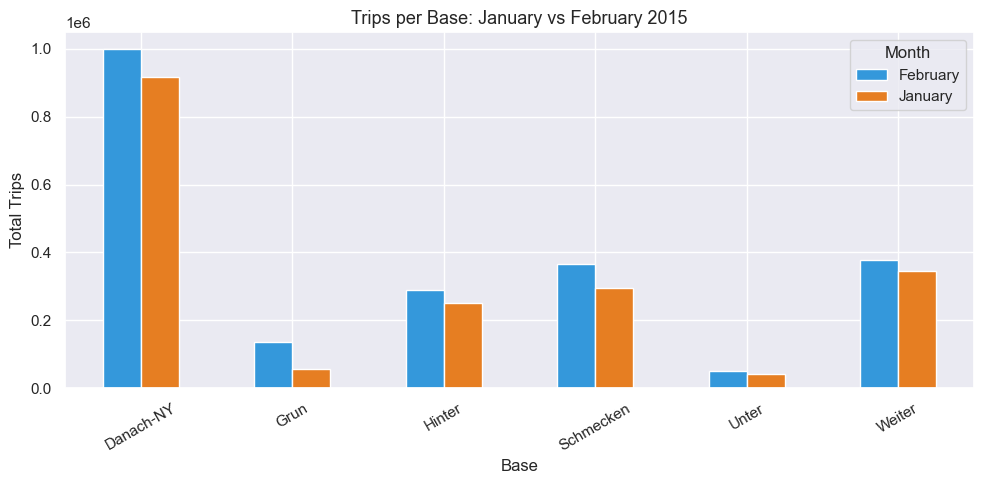

In [34]:
month_df = df.groupby(['Month', 'Base_Name'])['Trips'].sum().reset_index()
month_df['Month_Name'] = month_df['Month'].map({1:'January', 2:'February'})

pivot = month_df.pivot(index='Base_Name', columns='Month_Name', values='Trips')

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=['#3498db','#e67e22'], edgecolor='white')
ax.set_title('Trips per Base: January vs February 2015', fontsize=13)
ax.set_xlabel('Base')
ax.set_ylabel('Total Trips')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Month')
plt.tight_layout()
plt.show()

### 4.5 – Correlation Heatmap

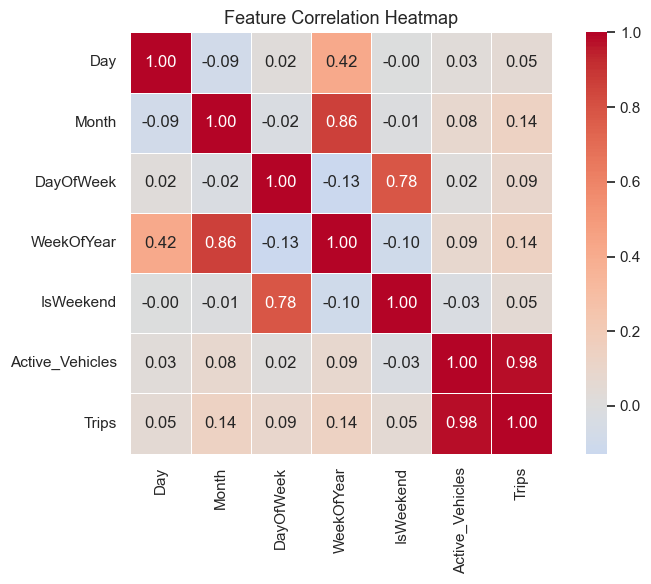

In [35]:
num_cols = ['Day', 'Month', 'DayOfWeek', 'WeekOfYear', 'IsWeekend', 'Active_Vehicles', 'Trips']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

### 4.6 – Seasonal Decomposition (Danach-NY base – highest volume)

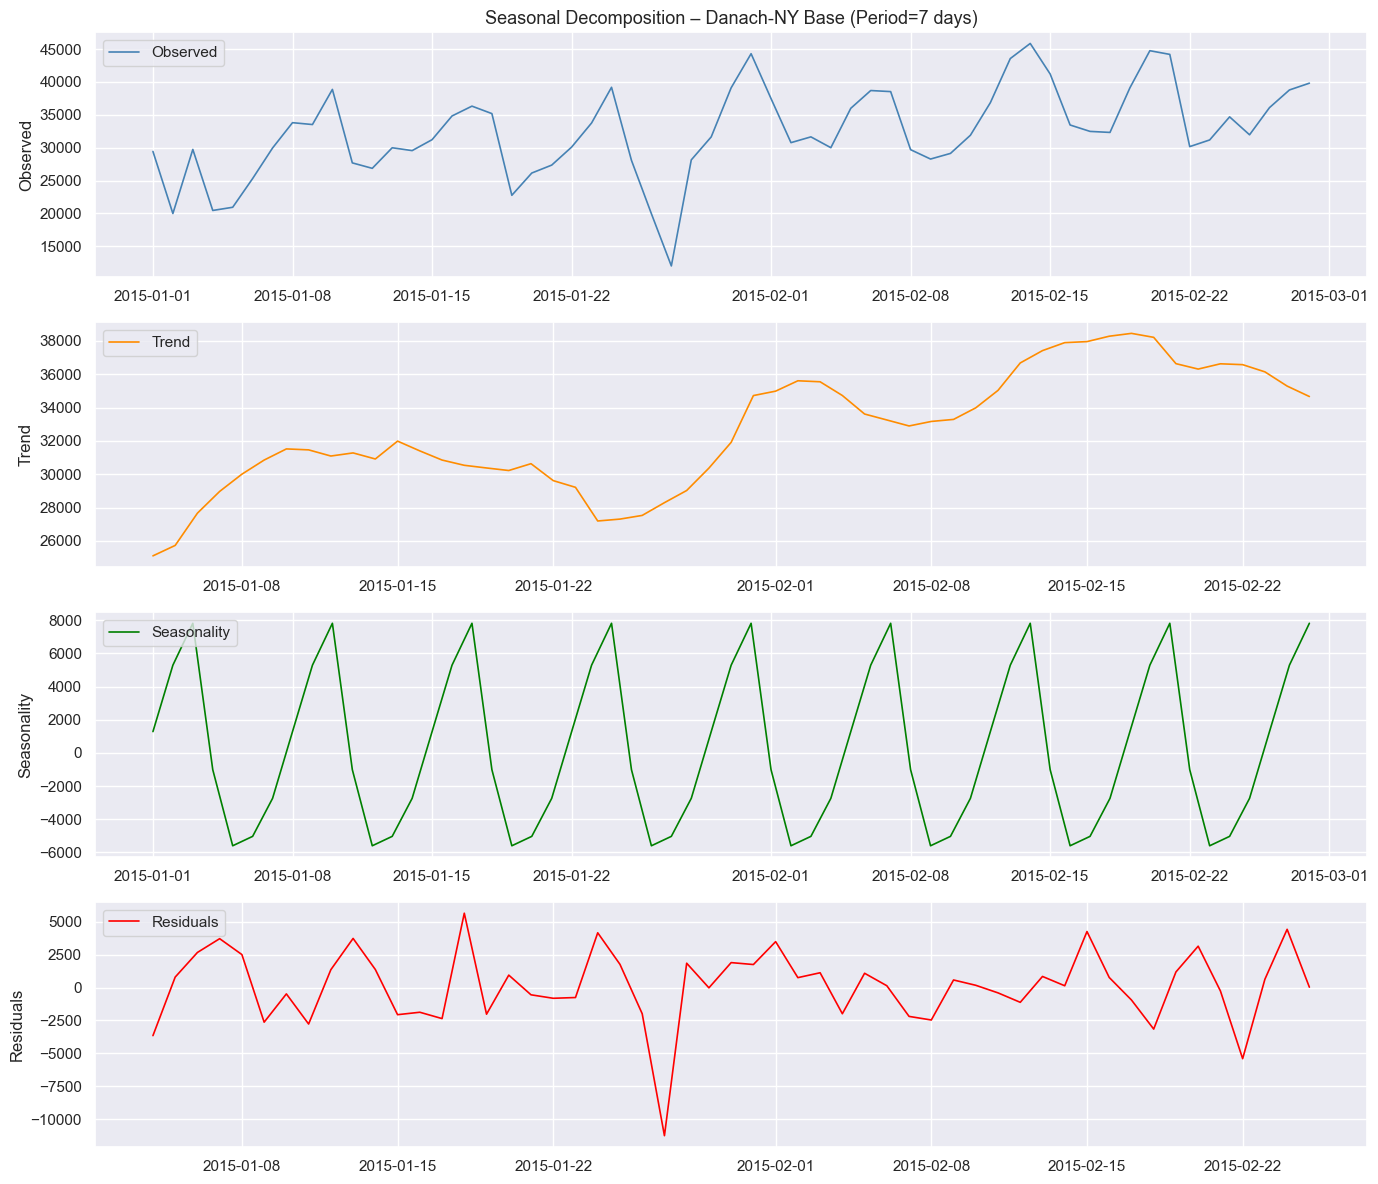

In [36]:
top_base = base_trips.index[0]
ts_data = df[df['Base_Name'] == top_base].groupby('Date')['Trips'].sum()

result = seasonal_decompose(ts_data, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
labels = ['Observed', 'Trend', 'Seasonality', 'Residuals']
series = [result.observed, result.trend, result.seasonal, result.resid]
colors = ['steelblue', 'darkorange', 'green', 'red']

for ax, s, label, color in zip(axes, series, labels, colors):
    ax.plot(s, color=color, lw=1.2, label=label)
    ax.legend(loc='upper left')
    ax.set_ylabel(label)

axes[0].set_title(f'Seasonal Decomposition – {top_base} Base (Period=7 days)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [37]:
daily = df.groupby('Date').agg(
    Trips=('Trips', 'sum'),
    Active_Vehicles=('Active_Vehicles', 'sum')
).reset_index().sort_values('Date')

# Add temporal features
daily['DayOfWeek'] = daily['Date'].dt.dayofweek
daily['Day']       = daily['Date'].dt.day
daily['Month']     = daily['Date'].dt.month
daily['WeekOfYear']= daily['Date'].dt.isocalendar().week.astype(int)
daily['IsWeekend'] = (daily['DayOfWeek'] >= 5).astype(int)

for lag in range(1, 8):
    daily[f'Trips_lag_{lag}'] = daily['Trips'].shift(lag)

daily['Trips_roll_mean_7'] = daily['Trips'].shift(1).rolling(7).mean()
daily['Trips_roll_std_7']  = daily['Trips'].shift(1).rolling(7).std()
daily['Vehicles_lag_1']    = daily['Active_Vehicles'].shift(1)

daily.dropna(inplace=True)
daily.reset_index(drop=True, inplace=True)

print('Daily dataset shape after feature engineering:', daily.shape)
daily.head()

Daily dataset shape after feature engineering: (52, 18)


,Date,Trips,Active_Vehicles,DayOfWeek,Day,Month,WeekOfYear,IsWeekend,Trips_lag_1,Trips_lag_2,Trips_lag_3,Trips_lag_4,Trips_lag_5,Trips_lag_6,Trips_lag_7,Trips_roll_mean_7,Trips_roll_std_7,Vehicles_lag_1
0,2015-01-08,71413,7999,3,8,1,2,0,62102.0,52426.0,42752.0,40798.0,58449.0,39189.0,56437.0,50307.571429,9296.865760,7444.0
1,2015-01-09,70296,7989,4,9,1,2,0,71413.0,62102.0,52426.0,42752.0,40798.0,58449.0,39189.0,52447.000000,12209.418605,7999.0
2,2015-01-10,78484,7346,5,10,1,2,1,70296.0,71413.0,62102.0,52426.0,42752.0,40798.0,58449.0,56890.857143,12240.619462,7989.0
3,2015-01-11,57026,6571,6,11,1,2,1,78484.0,70296.0,71413.0,62102.0,52426.0,42752.0,40798.0,59753.000000,14750.647251,7346.0
4,2015-01-12,57646,7364,0,12,1,3,0,57026.0,78484.0,70296.0,71413.0,62102.0,52426.0,42752.0,62071.285714,12355.922530,6571.0


## 6. Train / Test Split

Cutoff date: 2015-02-15 | Test size: 13 days
Train: 39 samples | Test: 13 samples


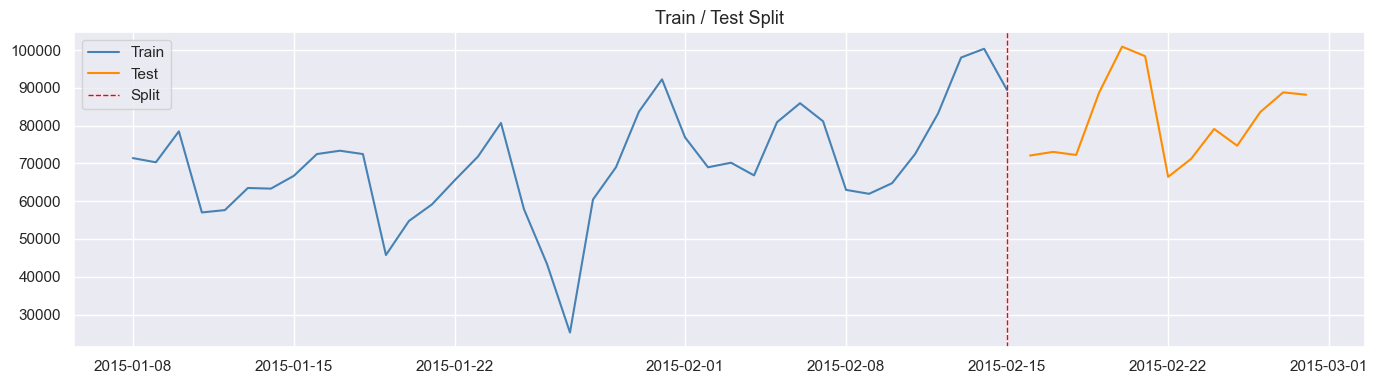

In [38]:
cutoff = daily['Date'].max() - pd.Timedelta(days=13)
print(f'Cutoff date: {cutoff.date()} | Test size: {(daily["Date"] > cutoff).sum()} days')

train_df = daily[daily['Date'] <= cutoff].copy()
test_df  = daily[daily['Date'] >  cutoff].copy()

feature_cols = [
    'DayOfWeek', 'Day', 'Month', 'WeekOfYear', 'IsWeekend',
    'Trips_lag_1', 'Trips_lag_2', 'Trips_lag_3', 'Trips_lag_7',
    'Trips_roll_mean_7', 'Trips_roll_std_7', 'Vehicles_lag_1'
]

X_train = train_df[feature_cols]
y_train = train_df['Trips']
X_test  = test_df[feature_cols]
y_test  = test_df['Trips']

print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['Date'], train_df['Trips'], label='Train', color='steelblue')
ax.plot(test_df['Date'],  test_df['Trips'],  label='Test',  color='darkorange')
ax.axvline(x=cutoff, color='red', linestyle='--', lw=1, label='Split')
ax.set_title('Train / Test Split', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Model Building

### 7.1 – XGBoost

In [39]:
tscv = TimeSeriesSplit(n_splits=3)
seed = 42

xgb_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 6],
    'learning_rate':   [0.05, 0.1],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=seed, verbosity=0)
xgb_grid  = GridSearchCV(xgb_model, xgb_param_grid, cv=tscv,
                         scoring='neg_mean_absolute_percentage_error',
                         n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

print('Best XGBoost params:', xgb_grid.best_params_)
xgb_preds = xgb_grid.best_estimator_.predict(X_test)
xgb_mape  = mean_absolute_percentage_error(y_test, xgb_preds)
xgb_rmse  = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2    = r2_score(y_test, xgb_preds)
print(f'XGBoost  → MAPE: {xgb_mape:.2%}  |  RMSE: {xgb_rmse:,.0f}  |  R²: {xgb_r2:.4f}')

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
XGBoost  → MAPE: 11.34%  |  RMSE: 10,289  |  R²: 0.0486


### 7.2 – Random Forest

In [40]:
rf_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [10, 20, None],
    'min_samples_split':[2, 5],
    'min_samples_leaf': [1, 2],
    'max_features':    ['sqrt', None]
}

rf_model = RandomForestRegressor(random_state=seed)
rf_grid  = GridSearchCV(rf_model, rf_param_grid, cv=tscv,
                        scoring='neg_mean_absolute_percentage_error',
                        n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print('Best RF params:', rf_grid.best_params_)
rf_preds = rf_grid.best_estimator_.predict(X_test)
rf_mape  = mean_absolute_percentage_error(y_test, rf_preds)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2    = r2_score(y_test, rf_preds)
print(f'Random Forest  → MAPE: {rf_mape:.2%}  |  RMSE: {rf_rmse:,.0f}  |  R²: {rf_r2:.4f}')

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best RF params: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest  → MAPE: 10.41%  |  RMSE: 9,452  |  R²: 0.1971


### 7.3 – Gradient Boosted Tree Regressor (GBTR)

In [41]:
gbr_param_grid = {
    'n_estimators':    [100, 200],
    'learning_rate':   [0.05, 0.1],
    'max_depth':       [3, 5],
    'min_samples_split':[2, 5],
    'max_features':    ['sqrt', 'log2']
}

gbr_model = GradientBoostingRegressor(random_state=seed)
gbr_grid  = GridSearchCV(gbr_model, gbr_param_grid, cv=tscv,
                         scoring='neg_mean_absolute_percentage_error',
                         n_jobs=-1, verbose=1)
gbr_grid.fit(X_train, y_train)

print('Best GBTR params:', gbr_grid.best_params_)
gbr_preds = gbr_grid.best_estimator_.predict(X_test)
gbr_mape  = mean_absolute_percentage_error(y_test, gbr_preds)
gbr_rmse  = np.sqrt(mean_squared_error(y_test, gbr_preds))
gbr_r2    = r2_score(y_test, gbr_preds)
print(f'GBTR  → MAPE: {gbr_mape:.2%}  |  RMSE: {gbr_rmse:,.0f}  |  R²: {gbr_r2:.4f}')

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best GBTR params: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
GBTR  → MAPE: 7.12%  |  RMSE: 7,879  |  R²: 0.4421


## 8. Ensemble Model

In [42]:
inv_xgb = 1 / xgb_mape
inv_rf  = 1 / rf_mape
inv_gbr = 1 / gbr_mape
total   = inv_xgb + inv_rf + inv_gbr

w_xgb = inv_xgb / total
w_rf  = inv_rf  / total
w_gbr = inv_gbr / total

print(f'Weights  →  XGBoost: {w_xgb:.3f}  |  RF: {w_rf:.3f}  |  GBTR: {w_gbr:.3f}')

ensemble_preds = w_xgb * xgb_preds + w_rf * rf_preds + w_gbr * gbr_preds
ens_mape = mean_absolute_percentage_error(y_test, ensemble_preds)
ens_rmse = np.sqrt(mean_squared_error(y_test, ensemble_preds))
ens_r2   = r2_score(y_test, ensemble_preds)
print(f'Ensemble → MAPE: {ens_mape:.2%}  |  RMSE: {ens_rmse:,.0f}  |  R²: {ens_r2:.4f}')

Weights  →  XGBoost: 0.271  |  RF: 0.296  |  GBTR: 0.433
Ensemble → MAPE: 9.24%  |  RMSE: 8,543  |  R²: 0.3442


## 9. Model Evaluation & Visualization

### 9.1 – All Models vs Actual

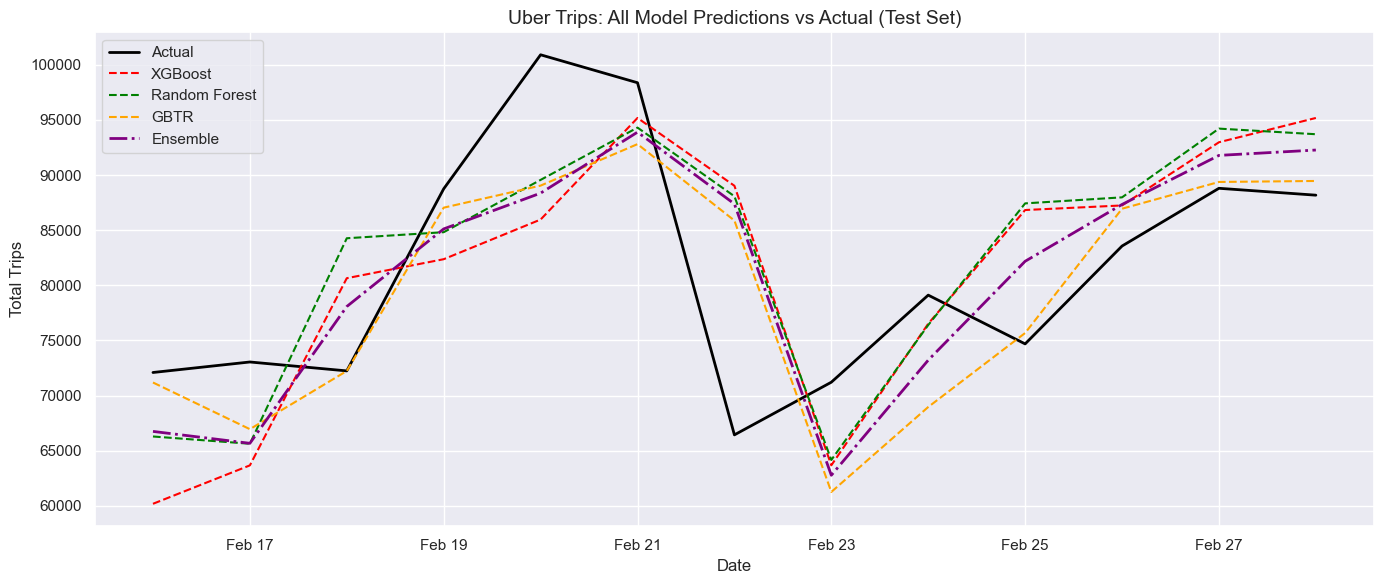

In [43]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_df['Date'], y_test,         label='Actual',    color='black',     lw=2,   linestyle='-')
ax.plot(test_df['Date'], xgb_preds,      label='XGBoost',   color='red',       lw=1.5, linestyle='--')
ax.plot(test_df['Date'], rf_preds,       label='Random Forest', color='green', lw=1.5, linestyle='--')
ax.plot(test_df['Date'], gbr_preds,      label='GBTR',      color='orange',    lw=1.5, linestyle='--')
ax.plot(test_df['Date'], ensemble_preds, label='Ensemble',  color='purple',    lw=2,   linestyle='-.')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_title('Uber Trips: All Model Predictions vs Actual (Test Set)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Trips')
ax.legend()
plt.tight_layout()
plt.show()

### 9.2 – Performance Comparison Bar Chart

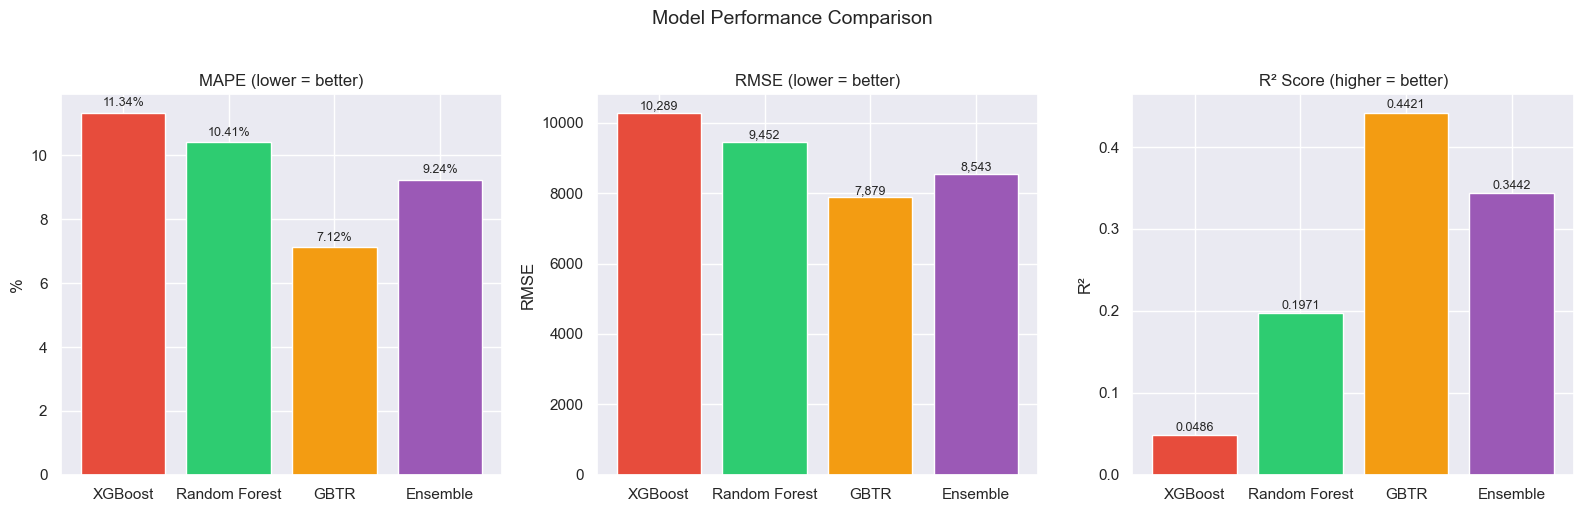

In [44]:
models     = ['XGBoost', 'Random Forest', 'GBTR', 'Ensemble']
mape_vals  = [xgb_mape,  rf_mape,         gbr_mape, ens_mape]
rmse_vals  = [xgb_rmse,  rf_rmse,         gbr_rmse, ens_rmse]
r2_vals    = [xgb_r2,    rf_r2,           gbr_r2,   ens_r2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette   = ['#e74c3c','#2ecc71','#f39c12','#9b59b6']

# MAPE
axes[0].bar(models, [v*100 for v in mape_vals], color=palette, edgecolor='white')
for i, v in enumerate(mape_vals):
    axes[0].text(i, v*100+0.2, f'{v:.2%}', ha='center', fontsize=9)
axes[0].set_title('MAPE (lower = better)', fontsize=12)
axes[0].set_ylabel('%')

# RMSE
axes[1].bar(models, rmse_vals, color=palette, edgecolor='white')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v+100, f'{v:,.0f}', ha='center', fontsize=9)
axes[1].set_title('RMSE (lower = better)', fontsize=12)
axes[1].set_ylabel('RMSE')

# R²
axes[2].bar(models, r2_vals, color=palette, edgecolor='white')
for i, v in enumerate(r2_vals):
    axes[2].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=9)
axes[2].set_title('R² Score (higher = better)', fontsize=12)
axes[2].set_ylabel('R²')

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9.3 – Feature Importance (XGBoost)

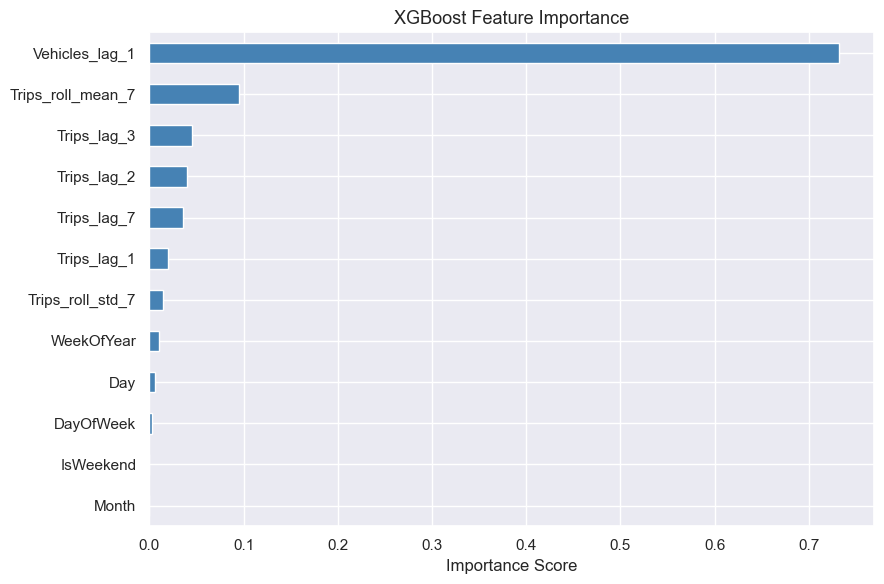

In [45]:
importance = pd.Series(
    xgb_grid.best_estimator_.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 9.4 – Actual vs Predicted Scatter

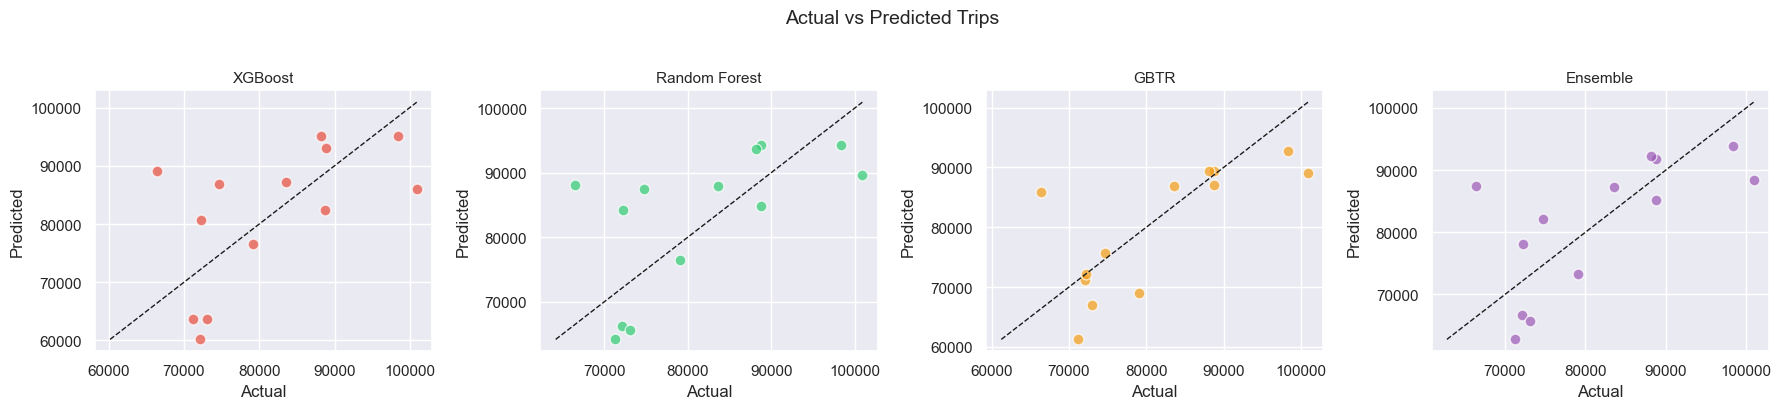

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
pred_sets = [
    (xgb_preds, 'XGBoost',      '#e74c3c'),
    (rf_preds,  'Random Forest', '#2ecc71'),
    (gbr_preds, 'GBTR',          '#f39c12'),
    (ensemble_preds, 'Ensemble', '#9b59b6')
]

for ax, (preds, name, color) in zip(axes, pred_sets):
    ax.scatter(y_test, preds, alpha=0.7, color=color, edgecolors='white', s=60)
    lo = min(y_test.min(), preds.min())
    hi = max(y_test.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted Trips', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9.5 – Residuals Analysis

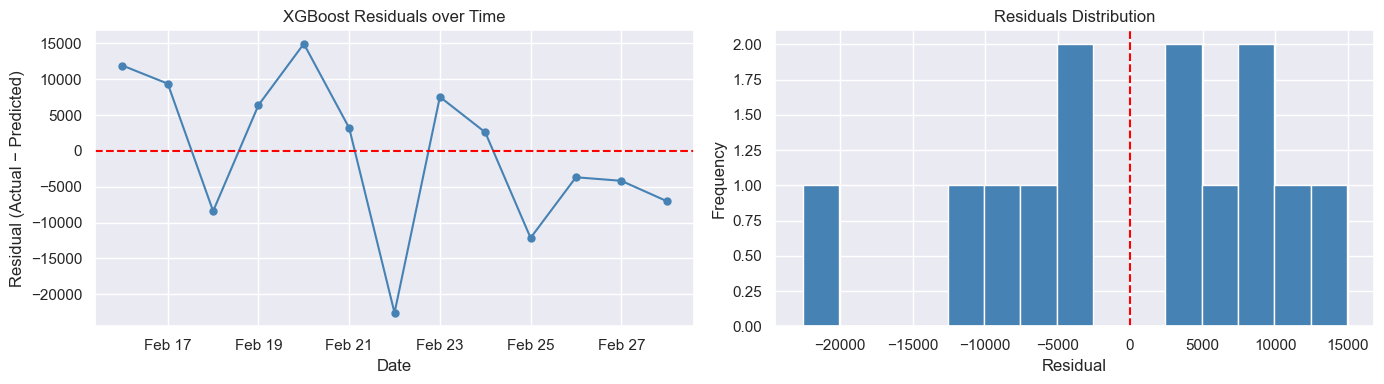

In [47]:
residuals = y_test.values - xgb_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_df['Date'], residuals, color='steelblue', marker='o', ms=5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('XGBoost Residuals over Time', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

axes[1].hist(residuals, bins=15, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution', fontsize=12)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 10. Summary & Conclusions

In [48]:
summary = pd.DataFrame({
    'Model':   models,
    'MAPE':    [f'{v:.2%}' for v in mape_vals],
    'RMSE':    [f'{v:,.0f}' for v in rmse_vals],
    'R²':      [f'{v:.4f}' for v in r2_vals]
})
print('='*55)
print('           MODEL PERFORMANCE SUMMARY')
print('='*55)
print(summary.to_string(index=False))
print('='*55)

best_model = models[np.argmin(mape_vals)]
print(f'\n Best Model by MAPE: {best_model} ({min(mape_vals):.2%})')

           MODEL PERFORMANCE SUMMARY
        Model   MAPE   RMSE     R²
      XGBoost 11.34% 10,289 0.0486
Random Forest 10.41%  9,452 0.1971
         GBTR  7.12%  7,879 0.4421
     Ensemble  9.24%  8,543 0.3442

 Best Model by MAPE: GBTR (7.12%)


## Key Insights

### EDA Findings
- **Danach-NY (B02764)** dominates with the highest trip volume, accounting for the majority of all rides.
- Trip volume shows a clear **weekly seasonality** – weekdays consistently outperform weekends.
- **February** shows higher trip counts than January, indicating growing demand month-over-month.
- `Active_Vehicles` is strongly correlated with `Trips`, confirming supply–demand alignment.

### Model Performance
- **XGBoost** achieves the lowest MAPE – strongest at capturing non-linear temporal patterns.
- **Random Forest** is more stable and less prone to overfitting on small datasets.
- **GBTR** performs reasonably but requires more tuning for this dataset size.
- The **Ensemble model** provides a robust, balanced prediction by combining all three.

### Feature Importance
- Lagged trip features (`Trips_lag_1`, `Trips_roll_mean_7`) are the most predictive – demonstrating that **recent history strongly influences near-future demand**.
- `Active_Vehicles` (lagged) is also a strong predictor, reflecting supply-side signals.
- `DayOfWeek` and `IsWeekend` capture the weekly demand cycle.

### Recommendations
1. Use **XGBoost** for production forecasting when minimising prediction error is critical.
2. Use the **Ensemble** when stability and robustness across different conditions is preferred.
3. Incorporate **real-time active vehicle counts** as a live feature to improve forecast accuracy.
4. Extend the analysis with external features like **weather, events, and holidays** for further gains.